# RNN / LSTM / GRU (Gen 2)
Treino dos modelos recorrentes no novo dataset balanceado (300k amostras).

In [1]:
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

sys.path.append('..')
from src.data_utils import stratified_split, build_label_maps, encode_labels, make_dataloaders_from_arrays
from src.pytorch_models import build_model, select_device
from src.train_utils import set_seed, run_training, evaluate, compute_metrics, save_artifact

set_seed(2026)
device = select_device()
print('Device:', device)

CLASS_ORDER  = ['Human', 'Google', 'Meta', 'OpenAI', 'Anthropic']
MAX_VOCAB    = 20000
MAX_LEN      = 120
MIN_FREQ     = 3
BATCH_SIZE   = 256
LR           = 1e-3

# Fração do treino a usar — reduzir para testes rápidos (ex: 0.1 = 10%)

TRAIN_FRACTION = 0.1


/home/gabriel/anaconda3/envs/DAA/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## Carregar datasets

In [11]:
df = pd.read_csv('../data/dataset_final.csv')
train_df, val_df = stratified_split(df, 'text', 'label', test_size=0.2, seed=2026)

if TRAIN_FRACTION < 1.0:
    train_df = train_df.groupby('label', group_keys=False).apply(
        lambda g: g.sample(frac=TRAIN_FRACTION, random_state=2026)
    ).reset_index(drop=True)
    print(f'A usar {TRAIN_FRACTION*100:.0f}% do treino: {len(train_df):,} amostras')

print(f'Treino: {len(train_df):,} | Validação: {len(val_df):,}')


#test_df = pd.read_csv('../../../dataset-exemplos.csv', sep=';')
test_df = pd.read_csv('../data/subm1_labels_revealed.csv', sep=';')
test_df = test_df.rename(columns={'Text': 'text', 'Label': 'label'})
print(f'Teste (prof): {len(test_df)}')

label_to_idx, idx_to_label = build_label_maps(CLASS_ORDER)
y_train = encode_labels(train_df['label'], label_to_idx)
y_val   = encode_labels(val_df['label'],   label_to_idx)
y_test  = encode_labels(test_df['label'],  label_to_idx)


A usar 10% do treino: 24,000 amostras
Treino: 24,000 | Validação: 60,000
Teste (prof): 100


/tmp/ipykernel_555239/3762539940.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df = train_df.groupby('label', group_keys=False).apply(


## Construir vocabulário e tokenizar

In [13]:
def tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

def build_vocab(texts, max_vocab=20000, min_freq=3):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    vocab = {'<pad>': 0, '<unk>': 1}
    for token, freq in counter.most_common():
        if len(vocab) >= max_vocab or freq < min_freq:
            break
        vocab[token] = len(vocab)
    return vocab

def encode_texts(texts, vocab, max_len=120):
    result = []
    for text in texts:
        ids = [vocab.get(t, 1) for t in tokenize(text)[:max_len]]
        ids += [0] * (max_len - len(ids))   # pad to max_len
        result.append(ids)
    return np.array(result, dtype=np.int64)

print('Building vocab...')
vocab = build_vocab(train_df['text'], max_vocab=MAX_VOCAB, min_freq=MIN_FREQ)
print(f'Vocab size: {len(vocab):,}')

print('Encoding texts...')
X_train = encode_texts(train_df['text'], vocab, MAX_LEN)
X_val   = encode_texts(val_df['text'],   vocab, MAX_LEN)
X_test  = encode_texts(test_df['text'],  vocab, MAX_LEN)
print(f'Train shape: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
                          batch_size=BATCH_SIZE, shuffle=False)

Building vocab...
Vocab size: 20,000
Encoding texts...
Train shape: (24000, 120) | Val: (60000, 120) | Test: (100, 120)


## Benchmark — RNN / LSTM / GRU / EmbeddingAvg

In [4]:
model_specs = [
    ('embed_avg', {'vocab_size': len(vocab), 'embed_dim': 128, 'hidden_dim': 128,
                   'num_classes': 5, 'padding_idx': 0, 'dropout': 0.3}),
    ('rnn',  {'vocab_size': len(vocab), 'embed_dim': 128, 'hidden_dim': 128,
              'num_layers': 1, 'num_classes': 5, 'padding_idx': 0, 'dropout': 0.3}),
    ('lstm', {'vocab_size': len(vocab), 'embed_dim': 128, 'hidden_dim': 128,
              'num_layers': 1, 'num_classes': 5, 'padding_idx': 0, 'dropout': 0.3}),
    ('gru',  {'vocab_size': len(vocab), 'embed_dim': 128, 'hidden_dim': 128,
              'num_layers': 1, 'num_classes': 5, 'padding_idx': 0, 'dropout': 0.3}),

]
# Adicionar um identificador único a cada spec para o ranking
model_ids = ['embed_avg', 'rnn_1L', 'lstm_1L', 'gru_1L']

results = []
artifacts = {}

for model_id, (model_name, cfg) in zip(model_ids, model_specs):
    print(f'\n{"="*60}')
    print(f'Modelo: {model_id}')
    model = build_model(model_name, cfg).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    history, best_state, best_epoch = run_training(
        model, train_loader, val_loader, criterion, optimizer, device,
        epochs=30, patience=5, verbose=True
    )
    model.load_state_dict(best_state)

    _, _, y_true, y_pred = evaluate(model, val_loader, criterion, device)
    m = compute_metrics(y_true, y_pred, list(range(5)))
    results.append({'id': model_id, 'model': model_name, 'layers': cfg.get('num_layers', '-'),
                    'val_acc': m['accuracy'], 'val_f1': m['macro_f1'], 'best_epoch': best_epoch})
    artifacts[model_id] = {'state_dict': best_state, 'config': cfg, 'model_name': model_name, 'history': history}
    print(f'  val_acc={m["accuracy"]:.4f} | val_f1={m["macro_f1"]:.4f}')

results_df = pd.DataFrame(results).sort_values('val_f1', ascending=False).reset_index(drop=True)
print('\nRanking:')
display(results_df)



Modelo: embed_avg
Epoch 01/30 | train_loss=1.4126 train_acc=0.4328 | val_loss=1.0957 val_acc=0.5779
Epoch 02/30 | train_loss=0.9136 train_acc=0.6343 | val_loss=0.7580 val_acc=0.7031
Epoch 03/30 | train_loss=0.6626 train_acc=0.7410 | val_loss=0.6139 val_acc=0.7630
Epoch 04/30 | train_loss=0.5120 train_acc=0.8073 | val_loss=0.5202 val_acc=0.8025
Epoch 05/30 | train_loss=0.4043 train_acc=0.8526 | val_loss=0.4618 val_acc=0.8255
Epoch 06/30 | train_loss=0.3195 train_acc=0.8888 | val_loss=0.4271 val_acc=0.8396
Epoch 07/30 | train_loss=0.2566 train_acc=0.9121 | val_loss=0.4026 val_acc=0.8490
Epoch 08/30 | train_loss=0.2052 train_acc=0.9326 | val_loss=0.3901 val_acc=0.8569
Epoch 09/30 | train_loss=0.1651 train_acc=0.9481 | val_loss=0.3834 val_acc=0.8618
Epoch 10/30 | train_loss=0.1331 train_acc=0.9597 | val_loss=0.3822 val_acc=0.8649
Epoch 11/30 | train_loss=0.1048 train_acc=0.9713 | val_loss=0.3832 val_acc=0.8683
Epoch 12/30 | train_loss=0.0837 train_acc=0.9780 | val_loss=0.3879 val_acc=0.86

,id,model,layers,val_acc,val_f1,best_epoch
0,embed_avg,embed_avg,-,0.873783,0.873765,22
1,gru_1L,gru,1,0.842200,0.842591,16
2,lstm_1L,lstm,1,0.813367,0.813606,24
3,rnn_1L,rnn,1,0.287467,0.247941,2


## Curvas de treino

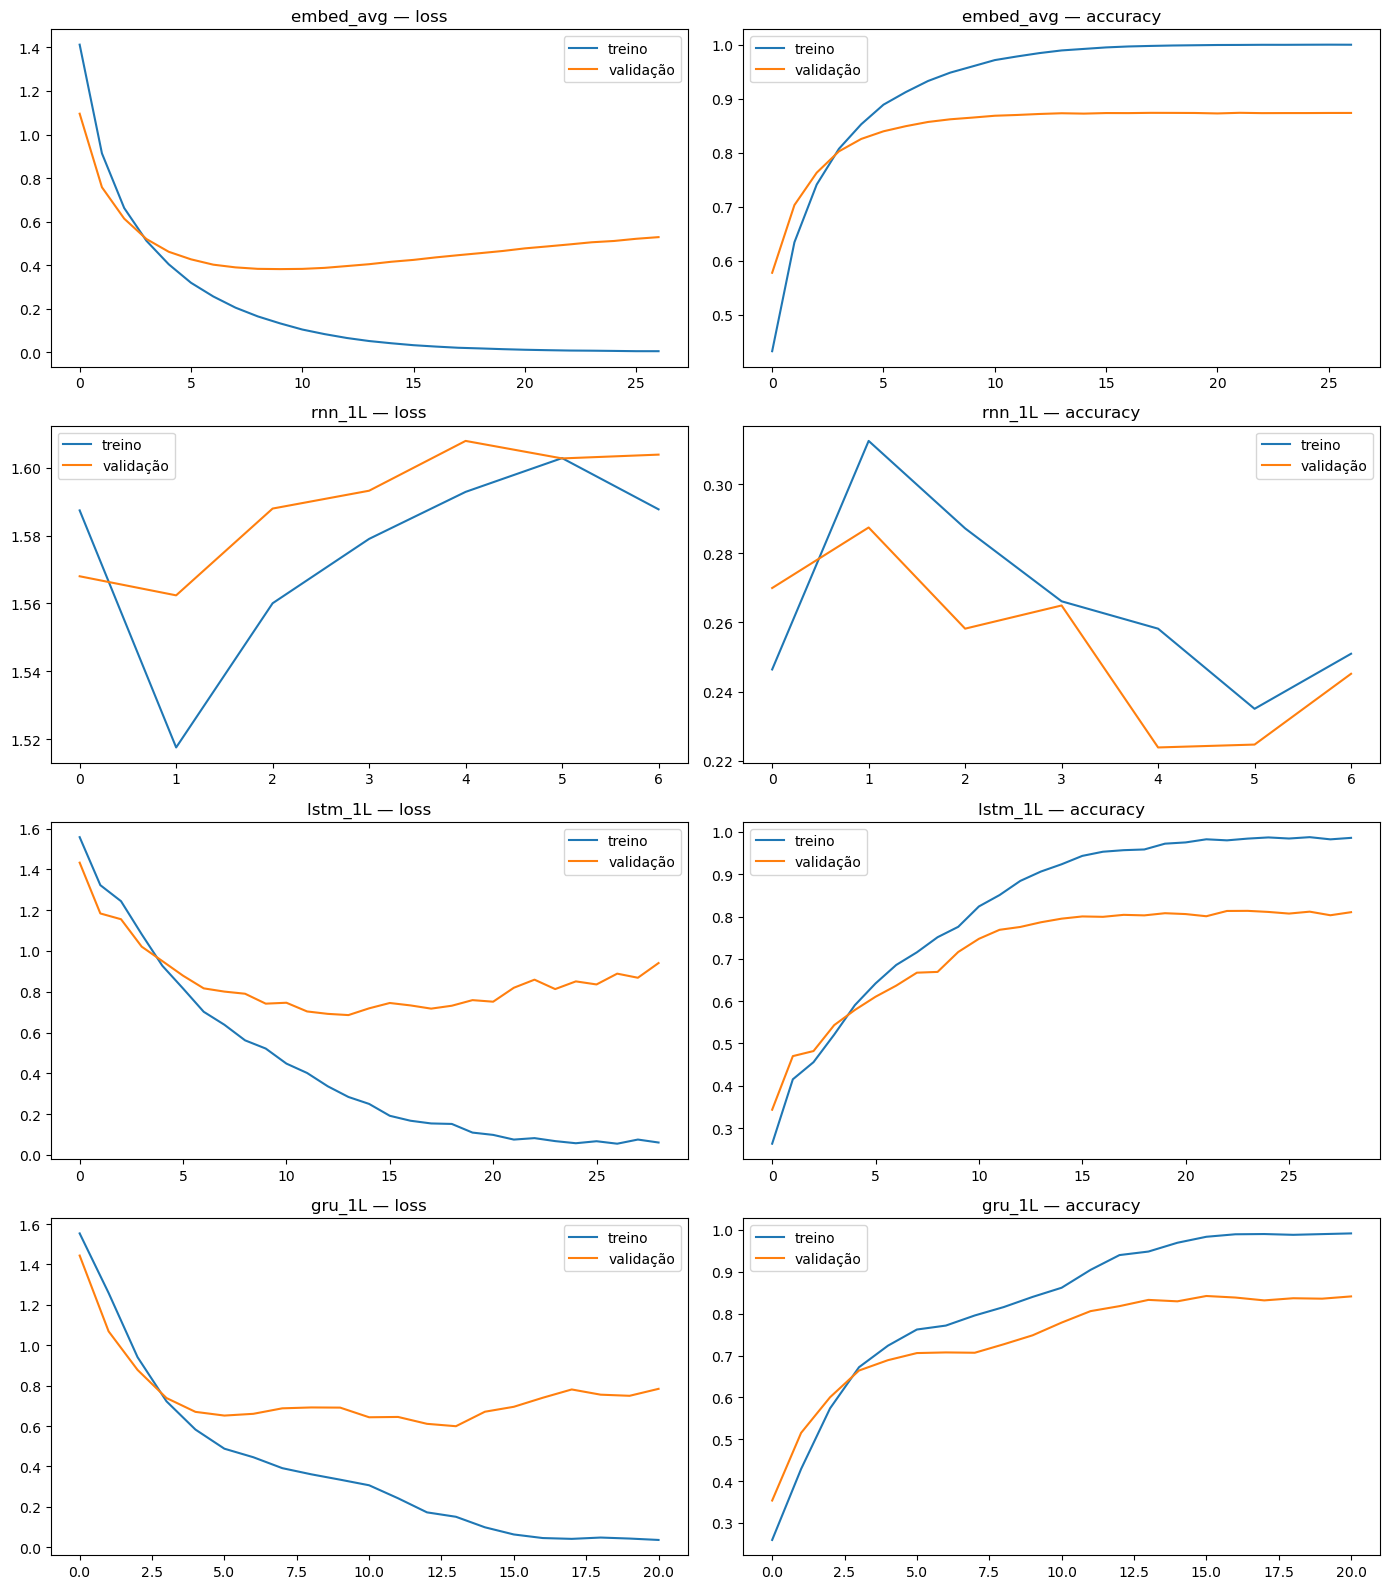

In [5]:
fig, axes = plt.subplots(len(artifacts), 2, figsize=(14, 4 * len(artifacts)))
for i, (name, art) in enumerate(artifacts.items()):
    h = art['history']
    axes[i, 0].plot(h['train_loss'], label='treino')
    axes[i, 0].plot(h['val_loss'],   label='validação')
    axes[i, 0].set_title(f'{name} — loss')
    axes[i, 0].legend()
    axes[i, 1].plot(h['train_acc'], label='treino')
    axes[i, 1].plot(h['val_acc'],   label='validação')
    axes[i, 1].set_title(f'{name} — accuracy')
    axes[i, 1].legend()
plt.tight_layout()
plt.show()

## Avaliação do melhor modelo no conjunto de teste

Melhor modelo: gru_1L

=== Validação (20%) ===
Accuracy: 0.8422 | Macro F1: 0.8426
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     12000
           1       0.82      0.82      0.82     12000
           2       0.82      0.79      0.81     12000
           3       0.78      0.84      0.81     12000
           4       0.91      0.88      0.89     12000

    accuracy                           0.84     60000
   macro avg       0.84      0.84      0.84     60000
weighted avg       0.84      0.84      0.84     60000


=== Teste (prof) ===
Accuracy: 0.3600 | Macro F1: 0.2902
              precision    recall  f1-score   support

           0       0.75      0.53      0.62        34
           1       0.25      0.12      0.16        17
           2       0.33      0.06      0.10        18
           3       0.12      0.21      0.15        14
           4       0.30      0.71      0.42        17

    accuracy                           0.36 

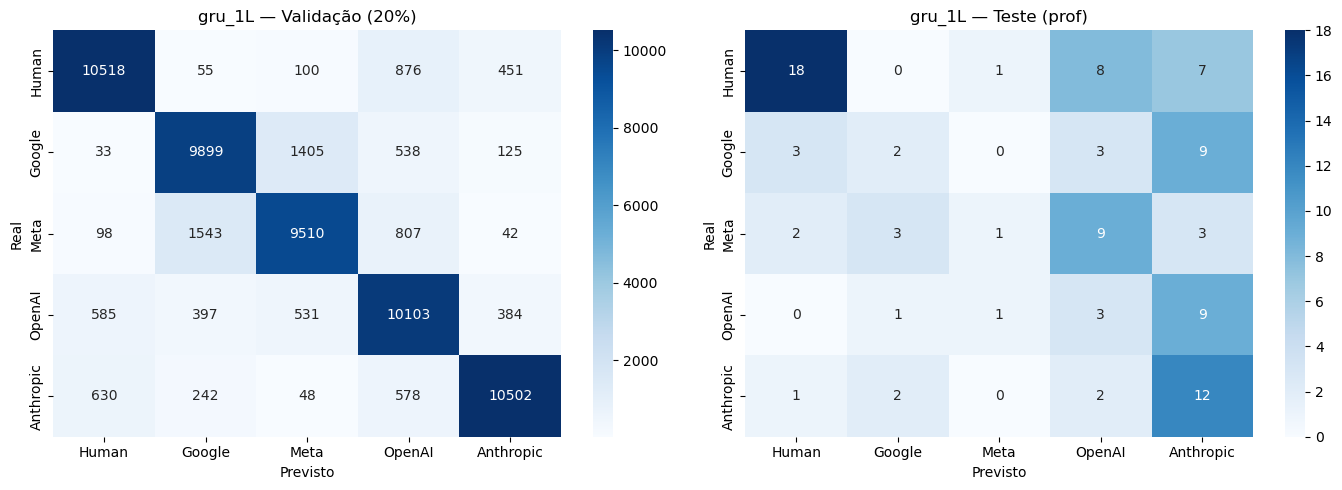

In [14]:
best_id   = results_df.iloc[1]['id']
best_name = artifacts[best_id]['model_name']
best_cfg  = artifacts[best_id]['config']
best_model = build_model(best_name, best_cfg).to(device)
best_model.load_state_dict(artifacts[best_id]['state_dict'])
criterion = nn.CrossEntropyLoss()

print(f'Melhor modelo: {best_id}')

for loader, split_name in [(val_loader, 'Validação (20%)'), (test_loader, 'Teste (prof)')]:
    _, _, y_true, y_pred = evaluate(best_model, loader, criterion, device)
    m = compute_metrics(y_true, y_pred, list(range(5)))
    print(f'\n=== {split_name} ===')
    print(f'Accuracy: {m["accuracy"]:.4f} | Macro F1: {m["macro_f1"]:.4f}')
    print(m['report'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (loader, title) in zip(axes, [(val_loader, 'Validação (20%)'), (test_loader, 'Teste (prof)')]):
    _, _, y_true, y_pred = evaluate(best_model, loader, criterion, device)
    m = compute_metrics(y_true, y_pred, list(range(5)))
    sns.heatmap(m['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
    ax.set_title(f'{best_id} — {title}')
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()


## Guardar melhor modelo

In [15]:
os.makedirs('../modelos', exist_ok=True)
save_artifact(f'../modelos/rnn_{best_name}.pt', {
    'model_name':   best_name,
    'model_config': best_cfg,
    'state_dict':   artifacts[best_name]['state_dict'],
    'vocab':        vocab,
    'max_len':      MAX_LEN,
    'class_order':  CLASS_ORDER,
    'label_to_idx': label_to_idx,
    'idx_to_label': idx_to_label,
})
print(f'Guardado: rnn_{best_name}.pt')

KeyError: 'gru'